### Visualize the similarity between DEGs within each of the contrasts

In [1]:
library(tidyverse)
library(reshape2)

── Attaching core tidyverse packages ────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────── tidyverse 2.0.0 ──
✔ dplyr     1.1.4     ✔ readr     2.1.5
✔ forcats   1.0.0     ✔ stringr   1.5.1
✔ ggplot2   3.5.2     ✔ tibble    3.3.0
✔ lubridate 1.9.4     ✔ tidyr     1.3.1
✔ purrr     1.1.0     
── Conflicts ──────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────── tidyverse_conflicts() ──
✖ dplyr::filter() masks stats::filter()
✖ dplyr::lag()    masks stats::lag()
ℹ Use the conflicted package (<http://conflicted.r-lib.org/>) to force all conflicts to become errors

Attaching package: ‘reshape2’


The following object is masked from ‘package:tidyr’:

    smiths




In [2]:
plots_dir <- "DESeq2_plots/"

In [3]:
contrasts <- c("age", "sex")
num_contrasts <- length(contrasts)

corresponding_contrast_file_names <- c("age_group_old_vs_young", "sex_male_vs_female")

cell_types <- c("Adipocyte", "Cardiomyocyte", "Endocardial", "Endothelial", "Epicardial",
              "Fibroblast", "Lymphoid", "LEC", "Mast", "Myeloid", "Neuronal", "Pericyte", "vSMC")

q_val_threshold <- 0.05
log2_FC_threshold <- 0.5

In [4]:
extract_up_and_down_genes <- function(DE_genes_df, q_val_threshold, log2_FC_threshold) {
    # obtain the number of DE genes that are up and down regulated
    up_df <- df %>% filter(padj <= q_val_threshold) %>% filter(log2FoldChange >= log2_FC_threshold)
    down_df <- df %>% filter(padj <= q_val_threshold) %>% filter(log2FoldChange <= -log2_FC_threshold)   

    up_sig_genes <- dim(up_df)[1]
    down_sig_genes <- dim(down_df)[1]

    return(list(up_sig_genes, down_sig_genes))
}

### Iterate through all cell types and create a df with all of the DEG genes

In [5]:
up_list <- list()
down_list <- list()

for (cell_type in cell_types) {

    for (i in 1:num_contrasts) {
        contrast_val <- contrasts[i]
        contrast_file_name <- corresponding_contrast_file_names[i]
        contrast_file_path <- paste0("pydeseq2_results/", cell_type, "_", contrast_file_name, "_results.csv")

        if (file.exists(contrast_file_path)) {
            df <- read.csv(contrast_file_path, row.names = 1)
            # add additional columns
            df$cell_type <- cell_type
            df$contrast <- contrast_val

            # create separate dfs for up and down DEGs
            up_df <- df %>% filter(padj <= q_val_threshold) %>% filter(log2FoldChange >= log2_FC_threshold)
            down_df <- df %>% filter(padj <= q_val_threshold) %>% filter(log2FoldChange <= -log2_FC_threshold)

            up_list[[length(up_list) + 1]] <- up_df
            down_list[[length(down_list) + 1]] <- down_df
        }
    }
}

# combine all up and down genes
up_DEGs_combined_df <- bind_rows(up_list)
down_DEGs_combined_df <- bind_rows(down_list)

In [6]:
dim(up_DEGs_combined_df)
dim(down_DEGs_combined_df)

[1] 419  11

[1] 508  11

#### Compute the Jaccard similarity of DEGs for the same contrast, across all cell types. Do this for all 4 contrasts.

In [7]:
jaccard_similarity <- function(set1, set2) {
  length(intersect(set1, set2)) / length(union(set1, set2))
}

In [8]:
# function to compute the Jaccard similarity for all DEGs across cell types in DEG_df, for the specific contrast
compute_jaccard_similarity_for_contrast <- function(contrast_of_interest, DEG_df) {
    
    # filter the df to contrast of interest
    filtered_df <- DEG_df %>%
  filter(contrast == contrast_of_interest)

    # group the DEGs by cell type and store as a list of sets of DEGs
    cell_type_gene_list <- filtered_df %>%
    group_by(cell_type) %>%
    summarize(genes = list(gene_id)) %>%
    pull(genes) %>%
    setNames(filtered_df$cell_type %>% unique())

    # iterate through all cell type comparisons
    cell_types <- names(cell_type_gene_list)

    # create matrix to store the Jaccard similarity
    jaccard_matrix <- matrix(0, nrow = length(cell_types), ncol = length(cell_types),
                         dimnames = list(cell_types, cell_types))
    # iterate through all cell types
    for (i in seq_along(cell_types)) {
        for (j in seq_along(cell_types)) {
    jaccard_matrix[i, j] <- jaccard_similarity(cell_type_gene_list[[i]], cell_type_gene_list[[j]])
        }
    }

    # convert the matrix 
    jaccard_df <- melt(jaccard_matrix) %>%
        rename(cell_type_1 = Var1, cell_type_2 = Var2, similarity = value)

    # produce plot
    p1 <- ggplot(jaccard_df, aes(x = cell_type_1, y = cell_type_2, fill = similarity)) +
      geom_tile(color = "white") +
      scale_fill_gradient(low = "white", high = "blue", name = "Jaccard\nSimilarity") +
      theme_minimal() +
      theme(axis.text.x = element_text(angle = 90, vjust = 0.5, hjust = 1, size = 12),
            axis.text.y = element_text(size = 12),
        axis.title.x = element_blank(),
        axis.title.y = element_blank()) +
      labs(title = paste("Jaccard Similarity for", contrast_of_interest))

    # return the Jaccard similarity matrix and plot

    return(list(jaccard_matrix, p1))
}

### Produce jaccard plots for up DEGs

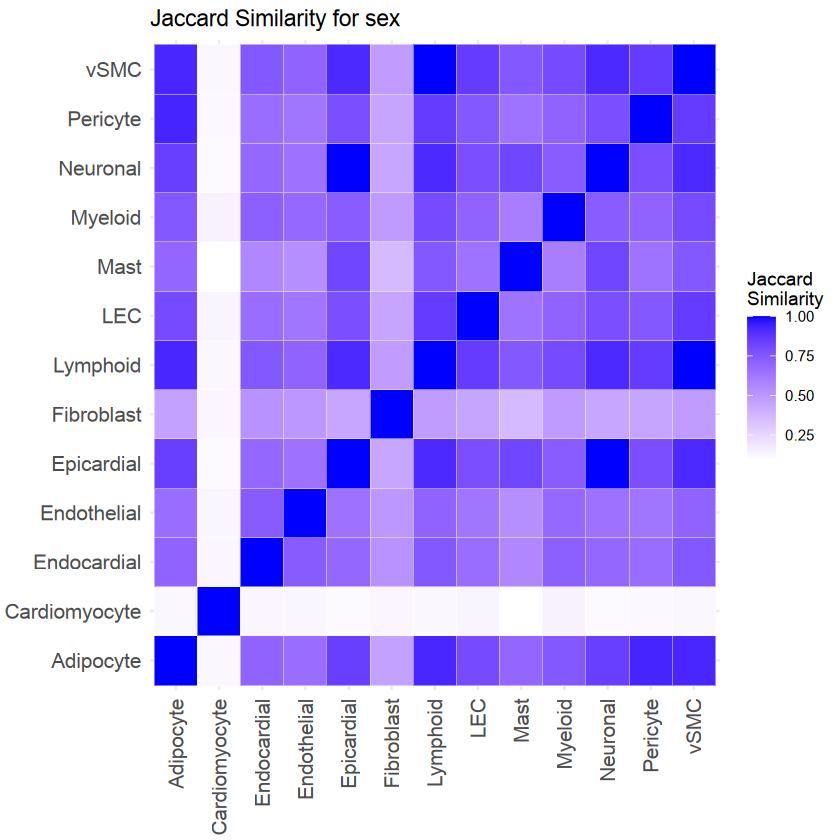

In [9]:
results <- compute_jaccard_similarity_for_contrast(contrast_of_interest = "sex", DEG_df = up_DEGs_combined_df)
results[[2]]

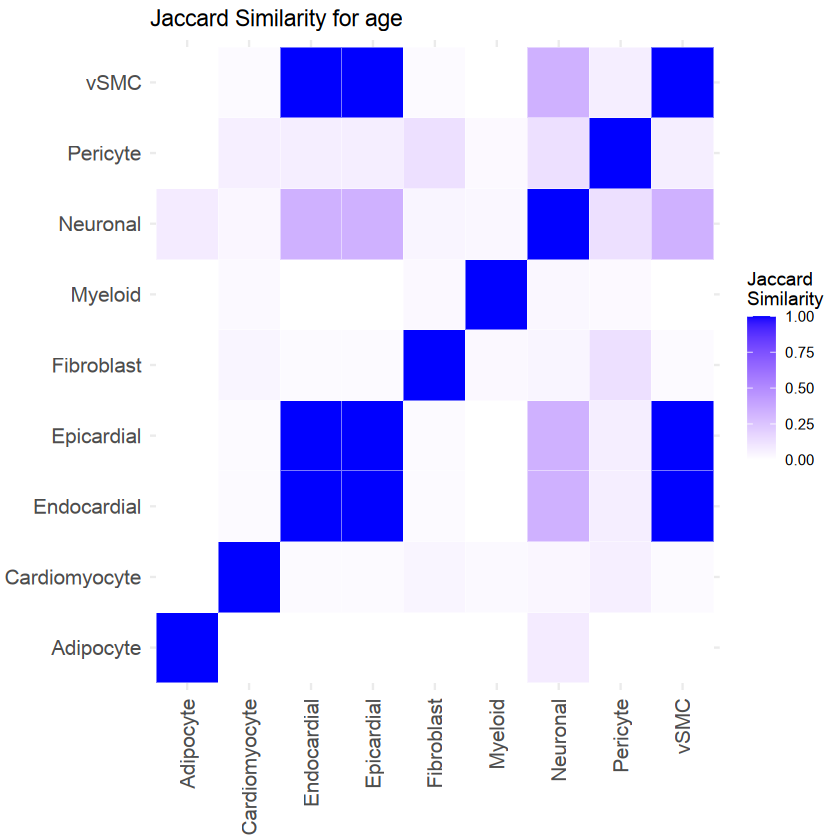

In [10]:
results <- compute_jaccard_similarity_for_contrast(contrast_of_interest = "age", DEG_df = up_DEGs_combined_df)
results[[2]]

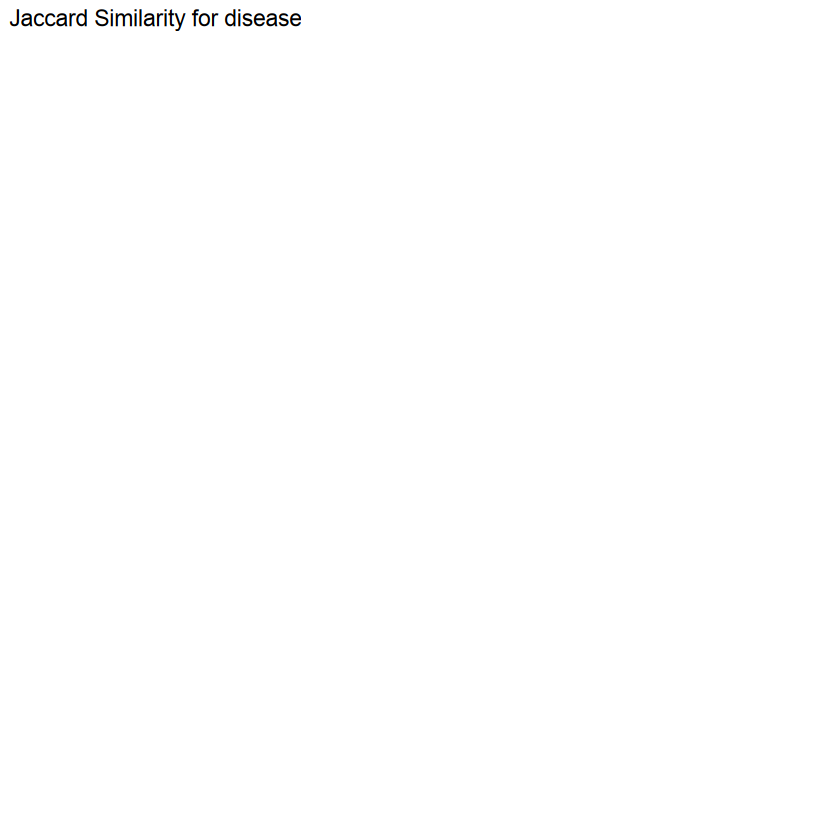

In [11]:
results <- compute_jaccard_similarity_for_contrast(contrast_of_interest = "disease", DEG_df = up_DEGs_combined_df)
results[[2]]

### Compute Jaccard similarity for down DEGs

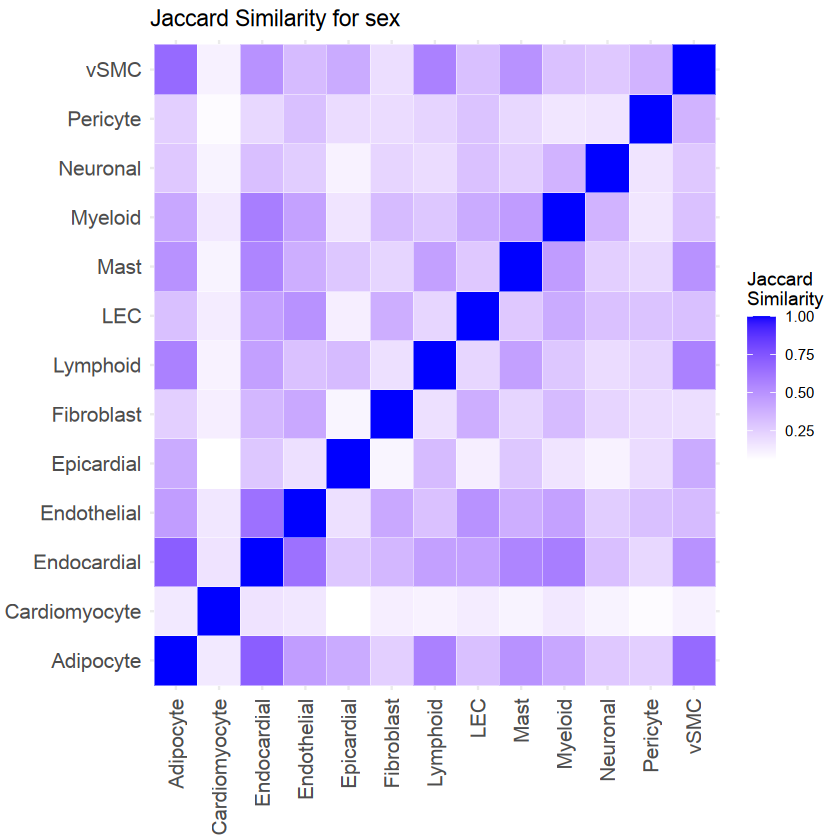

In [12]:
results <- compute_jaccard_similarity_for_contrast(contrast_of_interest = "sex", DEG_df = down_DEGs_combined_df)
results[[2]]

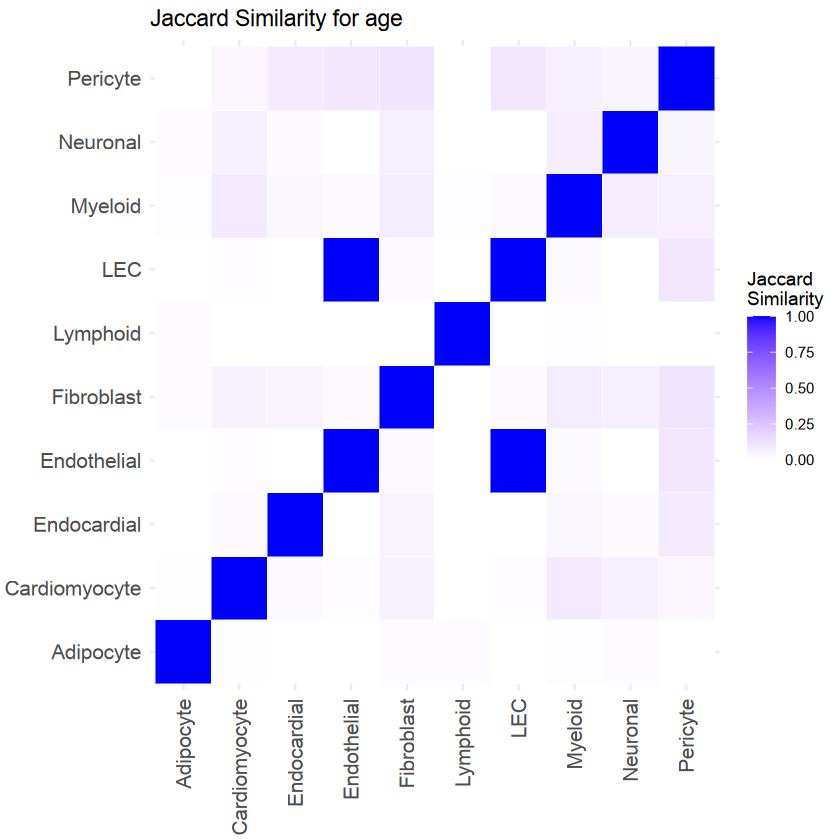

In [13]:
results <- compute_jaccard_similarity_for_contrast(contrast_of_interest = "age", DEG_df = down_DEGs_combined_df)
results[[2]]

### Another analysis is to identify which genes are consistently DEG across cell types

In [14]:
get_common_DEGs_across_cell_types <- function(contrast_of_interest, DEG_df) {

    # filter the df to contrast of interest
    filtered_df <- DEG_df %>% filter(contrast == contrast_of_interest)

    # group the DEGs by cell type and store as a list of sets of DEGs
    cell_type_gene_list <- filtered_df %>%
    group_by(cell_type) %>%
    summarize(genes = list(gene_id)) %>%
    pull(genes) %>%
    setNames(filtered_df$cell_type %>% unique())

    # convert list to df
    genes_across_cell_types <- cell_type_gene_list %>%
    enframe(name = "cell_type", value = "genes") %>% 
    unnest(cols = c(genes)) 

    # return the number of cell types for which that gene is a DEG
    gene_cell_type_counts <- genes_across_cell_types %>%
    group_by(genes) %>%
    summarize(num_cell_types = n(), cell_types = paste(unique(cell_type), collapse = ", ")) %>%
    arrange(desc(num_cell_types))

    # save this as a histogram too
    p2 <- ggplot(data = gene_cell_type_counts, mapping = aes(x = num_cell_types)) + geom_histogram() + theme_bw() +
    theme(legend.text = element_text(size = 16), 
         legend.title = element_text(size = 16), 
         plot.title = element_text(size = 24, hjust = 0.5), 
         axis.title.x = element_text(size = 16),
         axis.title.y = element_text(size = 16),
         axis.text.x = element_text(size = 16),
         axis.text.y = element_text(size = 16),
	 strip.text = element_text(size = 18))
    
    return(list(gene_cell_type_counts, p2))

}

#### Perform for up DEGs

[1] "age"
# A tibble: 133 × 5
   genes   num_cell_types cell_types                          contrast direction
   <chr>            <int> <chr>                               <chr>    <chr>    
 1 PTCHD4               7 Cardiomyocyte, Endocardial, Epicar… age      up       
 2 ITLN1                5 Cardiomyocyte, Fibroblast, Myeloid… age      up       
 3 NAP1L2               3 Cardiomyocyte, Fibroblast, Pericyte age      up       
 4 TNNI3                3 Cardiomyocyte, Fibroblast, Pericyte age      up       
 5 EDA2R                2 Fibroblast, Pericyte                age      up       
 6 HBA1                 2 Fibroblast, Myeloid                 age      up       
 7 KRT19                2 Cardiomyocyte, Myeloid              age      up       
 8 SPATA18              2 Fibroblast, Pericyte                age      up       
 9 XG                   2 Fibroblast, Pericyte                age      up       
10 ZER1                 2 Adipocyte, Neuronal                 age      up      

`stat_bin()` using `bins = 30`. Pick better value with `binwidth`.


[1] "sex"
# A tibble: 117 × 5
   genes     num_cell_types cell_types                        contrast direction
   <chr>              <int> <chr>                             <chr>    <chr>    
 1 DDX3Y                 13 Adipocyte, Cardiomyocyte, Endoca… sex      up       
 2 EIF1AY                13 Adipocyte, Cardiomyocyte, Endoca… sex      up       
 3 KDM5D                 13 Adipocyte, Cardiomyocyte, Endoca… sex      up       
 4 LINC00278             13 Adipocyte, Cardiomyocyte, Endoca… sex      up       
 5 RPS4Y1                13 Adipocyte, Cardiomyocyte, Endoca… sex      up       
 6 TTTY14                13 Adipocyte, Cardiomyocyte, Endoca… sex      up       
 7 USP9Y                 13 Adipocyte, Cardiomyocyte, Endoca… sex      up       
 8 UTY                   13 Adipocyte, Cardiomyocyte, Endoca… sex      up       
 9 ZFY                   13 Adipocyte, Cardiomyocyte, Endoca… sex      up       
10 NLGN4Y                12 Adipocyte, Cardiomyocyte, Endoca… sex      up      

`stat_bin()` using `bins = 30`. Pick better value with `binwidth`.


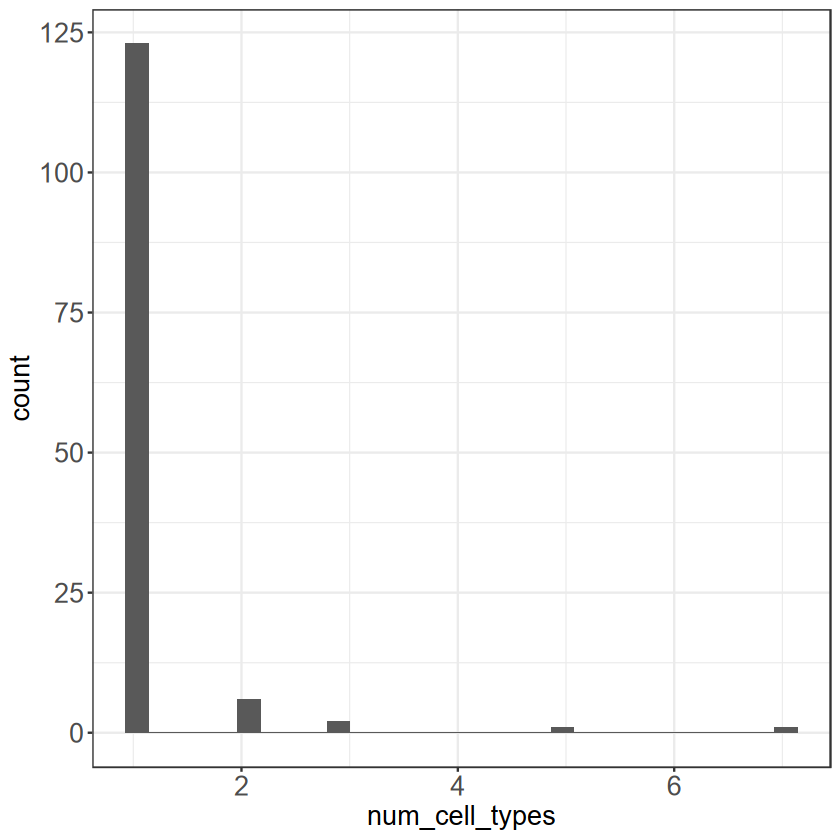

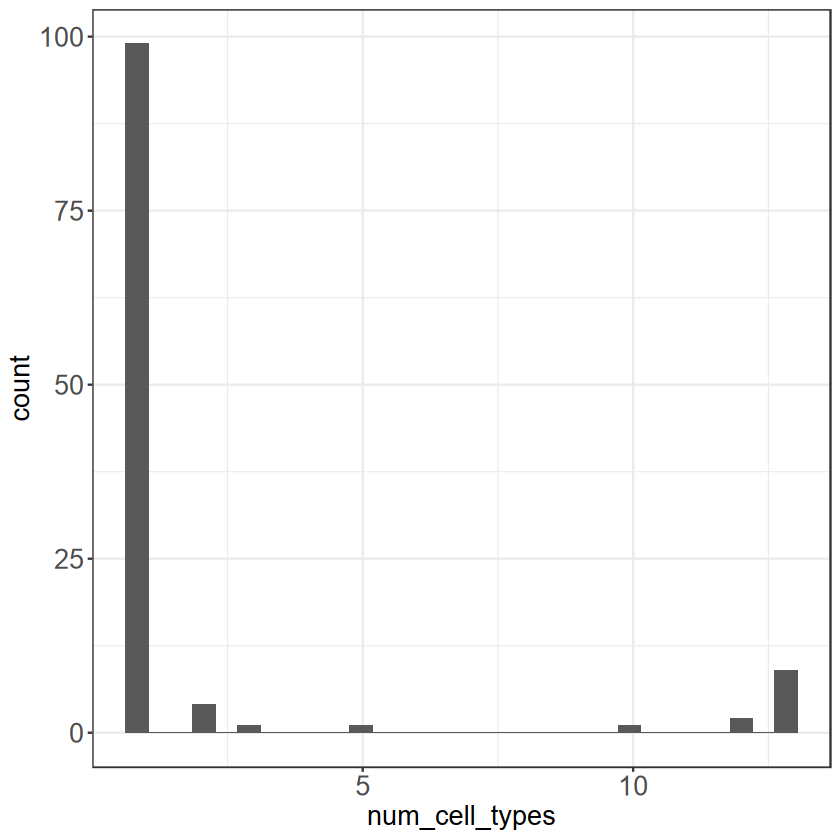

In [15]:
up_DEGs_results_list <- list() 

for (contrast in contrasts) {
    print(contrast)
    
    results <- get_common_DEGs_across_cell_types(contrast_of_interest = contrast, DEG_df = up_DEGs_combined_df)
    results_df <- results[[1]]
    results_df$contrast <- contrast
    results_df$direction <- "up"
    
    up_DEGs_results_list[[contrast]] <- results_df
    print(results_df)
    print(results[[2]])
    flush.console()
}

In [31]:
up_DEGs_results_list$age

genes,num_cell_types,cell_types,contrast,direction
<chr>,<int>,<chr>,<chr>,<chr>
PTCHD4,7,"Cardiomyocyte, Endocardial, Epicardial, Fibroblast, Neuronal, Pericyte, vSMC",age,up
ITLN1,5,"Cardiomyocyte, Fibroblast, Myeloid, Neuronal, Pericyte",age,up
NAP1L2,3,"Cardiomyocyte, Fibroblast, Pericyte",age,up
TNNI3,3,"Cardiomyocyte, Fibroblast, Pericyte",age,up
EDA2R,2,"Fibroblast, Pericyte",age,up
HBA1,2,"Fibroblast, Myeloid",age,up
KRT19,2,"Cardiomyocyte, Myeloid",age,up
SPATA18,2,"Fibroblast, Pericyte",age,up
XG,2,"Fibroblast, Pericyte",age,up


In [33]:
down_DEGs_results_list$sex

genes,num_cell_types,cell_types,contrast,direction
<chr>,<int>,<chr>,<chr>,<chr>
TSIX,13,"Adipocyte, Cardiomyocyte, Endocardial, Endothelial, Epicardial, Fibroblast, Lymphoid, LEC, Mast, Myeloid, Neuronal, Pericyte, vSMC",sex,down
XIST,13,"Adipocyte, Cardiomyocyte, Endocardial, Endothelial, Epicardial, Fibroblast, Lymphoid, LEC, Mast, Myeloid, Neuronal, Pericyte, vSMC",sex,down
KDM6A,12,"Adipocyte, Cardiomyocyte, Endocardial, Endothelial, Fibroblast, Lymphoid, LEC, Mast, Myeloid, Neuronal, Pericyte, vSMC",sex,down
JPX,11,"Adipocyte, Cardiomyocyte, Endocardial, Endothelial, Fibroblast, Lymphoid, LEC, Mast, Myeloid, Neuronal, vSMC",sex,down
ZFX,8,"Adipocyte, Cardiomyocyte, Endocardial, Endothelial, Fibroblast, LEC, Myeloid, Neuronal",sex,down
EIF1AX,7,"Endocardial, Endothelial, Fibroblast, LEC, Mast, Myeloid, Neuronal",sex,down
KDM5C,6,"Cardiomyocyte, Endocardial, Endothelial, Fibroblast, LEC, Myeloid",sex,down
CA5B,4,"LEC, Neuronal, Pericyte, vSMC",sex,down
DDX3X,4,"Endothelial, Fibroblast, LEC, Pericyte",sex,down


In [34]:
down_DEGs_results_list$age

genes,num_cell_types,cell_types,contrast,direction
<chr>,<int>,<chr>,<chr>,<chr>
COL3A1,6,"Cardiomyocyte, Endothelial, Fibroblast, LEC, Myeloid, Pericyte",age,down
GGT5,5,"Cardiomyocyte, Fibroblast, Myeloid, Neuronal, Pericyte",age,down
MYH6,5,"Cardiomyocyte, Endocardial, Fibroblast, Myeloid, Neuronal",age,down
COL1A1,4,"Cardiomyocyte, Fibroblast, Myeloid, Neuronal",age,down
COL1A2,4,"Cardiomyocyte, Myeloid, Neuronal, Pericyte",age,down
FCN3,4,"Cardiomyocyte, Fibroblast, Myeloid, Pericyte",age,down
EMILIN1,3,"Cardiomyocyte, Endocardial, Myeloid",age,down
NRCAM,3,"Adipocyte, Fibroblast, Neuronal",age,down
PDGFRA,3,"Cardiomyocyte, Fibroblast, Myeloid",age,down


### Perform for down DEGs

[1] "age"
# A tibble: 303 × 5
   genes   num_cell_types cell_types                          contrast direction
   <chr>            <int> <chr>                               <chr>    <chr>    
 1 COL3A1               6 Cardiomyocyte, Endothelial, Fibrob… age      down     
 2 GGT5                 5 Cardiomyocyte, Fibroblast, Myeloid… age      down     
 3 MYH6                 5 Cardiomyocyte, Endocardial, Fibrob… age      down     
 4 COL1A1               4 Cardiomyocyte, Fibroblast, Myeloid… age      down     
 5 COL1A2               4 Cardiomyocyte, Myeloid, Neuronal, … age      down     
 6 FCN3                 4 Cardiomyocyte, Fibroblast, Myeloid… age      down     
 7 EMILIN1              3 Cardiomyocyte, Endocardial, Myeloid age      down     
 8 NRCAM                3 Adipocyte, Fibroblast, Neuronal     age      down     
 9 PDGFRA               3 Cardiomyocyte, Fibroblast, Myeloid  age      down     
10 RANBP17              3 Endocardial, Fibroblast, Pericyte   age      down    

`stat_bin()` using `bins = 30`. Pick better value with `binwidth`.


[1] "sex"
# A tibble: 76 × 5
   genes  num_cell_types cell_types                           contrast direction
   <chr>           <int> <chr>                                <chr>    <chr>    
 1 TSIX               13 Adipocyte, Cardiomyocyte, Endocardi… sex      down     
 2 XIST               13 Adipocyte, Cardiomyocyte, Endocardi… sex      down     
 3 KDM6A              12 Adipocyte, Cardiomyocyte, Endocardi… sex      down     
 4 JPX                11 Adipocyte, Cardiomyocyte, Endocardi… sex      down     
 5 ZFX                 8 Adipocyte, Cardiomyocyte, Endocardi… sex      down     
 6 EIF1AX              7 Endocardial, Endothelial, Fibroblas… sex      down     
 7 KDM5C               6 Cardiomyocyte, Endocardial, Endothe… sex      down     
 8 CA5B                4 LEC, Neuronal, Pericyte, vSMC        sex      down     
 9 DDX3X               4 Endothelial, Fibroblast, LEC, Peric… sex      down     
10 MAP7D2              4 Endothelial, Fibroblast, LEC, Peric… sex      down     

`stat_bin()` using `bins = 30`. Pick better value with `binwidth`.


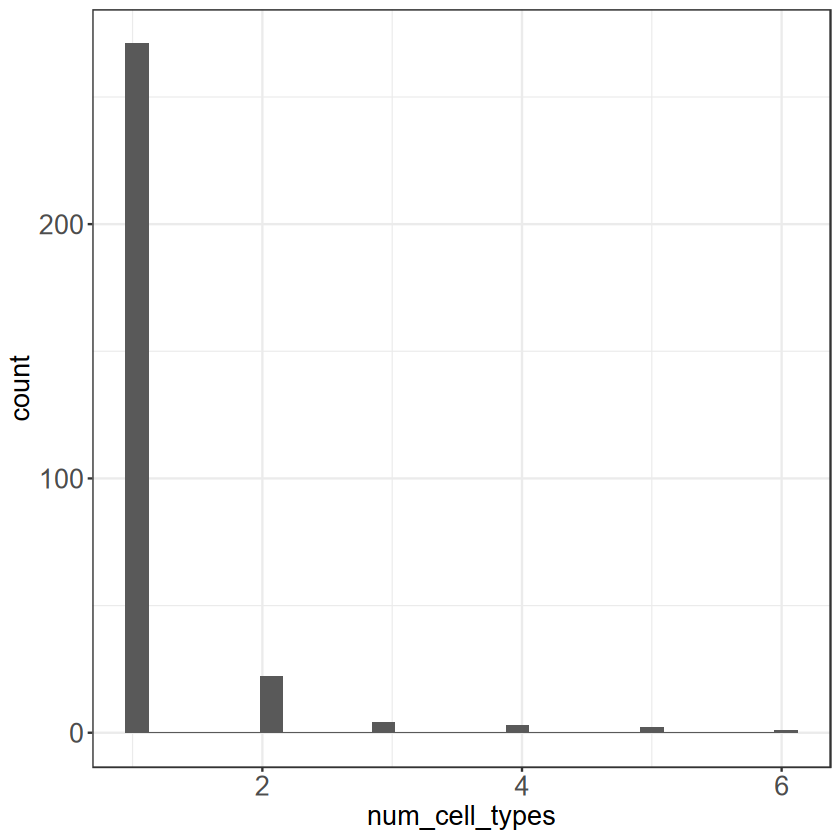

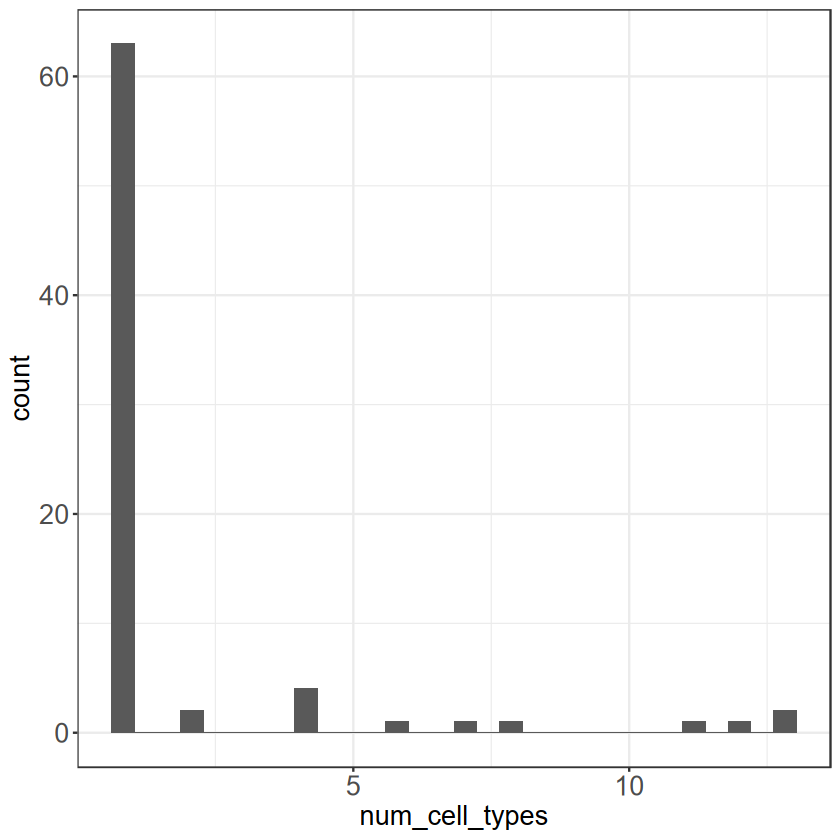

In [16]:
down_DEGs_results_list <- list()

for (contrast in contrasts) {
    print(contrast)
    
    results <- get_common_DEGs_across_cell_types(contrast_of_interest = contrast, DEG_df = down_DEGs_combined_df)
    results_df <- results[[1]]
    results_df$contrast <- contrast
    results_df$direction <- "down"
    
    down_DEGs_results_list[[contrast]] <- results_df
    print(results_df)
    print(results[[2]])
    flush.console()
}

### Produce plots for number of cell types sharing the same DEGs

In [19]:
combined_up_DEGs <- bind_rows(up_DEGs_results_list)
combined_down_DEGs <- bind_rows(down_DEGs_results_list)

combined_all_DEGs <- rbind(combined_up_DEGs, combined_down_DEGs)
combined_all_DEGs$contrast <- factor(combined_all_DEGs$contrast, c("sex", "age", "development", "disease"))

#### Get the mean number of genes sharing the DEGs

In [20]:
combined_all_DEGs %>% select(num_cell_types, contrast, direction) %>%
group_by(contrast, direction) %>% mutate(mean_cell_types = mean(num_cell_types)) %>% select(contrast, direction, mean_cell_types
) %>% distinct()

contrast,direction,mean_cell_types
<fct>,<chr>,<dbl>
age,up,1.150376
sex,up,2.273504
age,down,1.171617
sex,down,2.013158


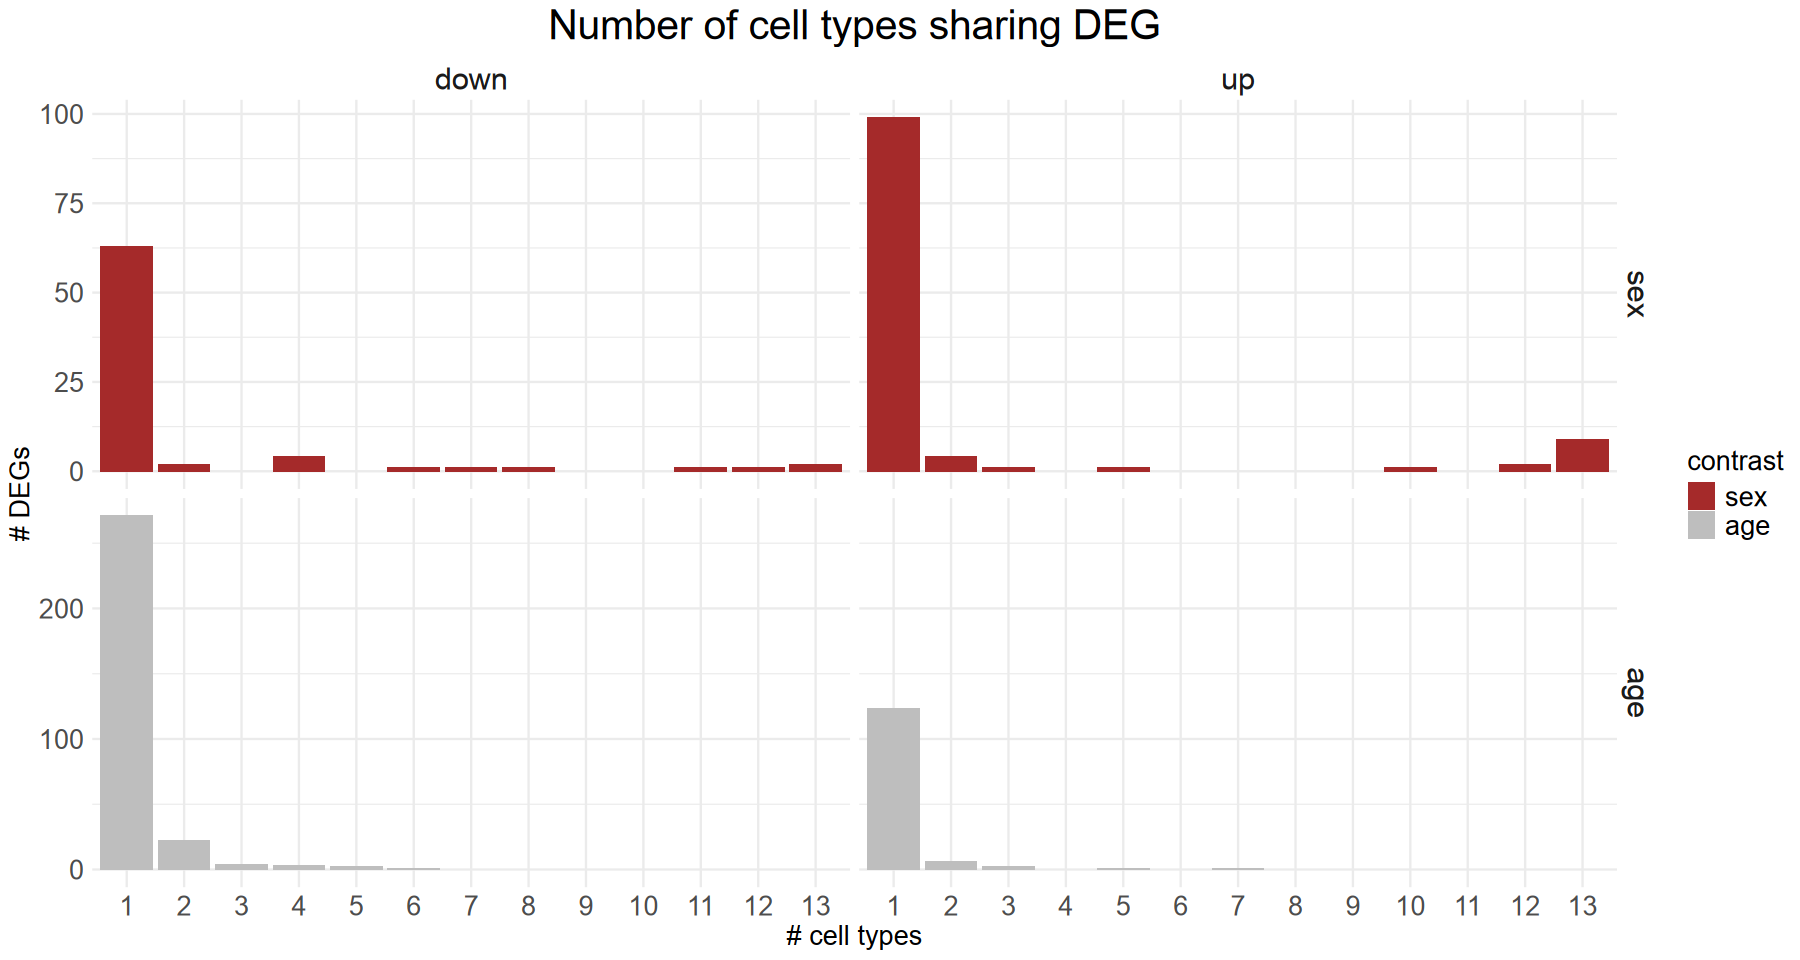

In [23]:
options(repr.plot.width = 15, repr.plot.height = 8)

p3 <- ggplot(data = combined_all_DEGs, mapping = aes(x = factor(num_cell_types), fill = contrast)) + 
  facet_grid(contrast ~ direction, scales = "free_y") + geom_bar() +  scale_x_discrete(limits = as.character(1:13)) +
  theme_minimal() + 
  theme(legend.text = element_text(size = 16), 
        legend.title = element_text(size = 16), 
        plot.title = element_text(size = 24, hjust = 0.5), 
        axis.title.x = element_text(size = 16),
        axis.title.y = element_text(size = 16),
        axis.text.x = element_text(size = 16),
        axis.text.y = element_text(size = 16),
        strip.text = element_text(size = 18)) +
  labs(title = "Number of cell types sharing DEG", 
       x = "# cell types", y = "# DEGs") +
  scale_fill_manual(values = c("brown", "gray", "#F8766D", "#619CFF"))  # Customize colors for contrast

ggsave(p3, filename = paste0(plots_dir, "04B_number_of_shared_DEGs_across_cell_types.pdf"), width = 15, height = 8)

p3